In [1]:
import sys

In [2]:
print(sys.executable)

/home/simonque/Documents/code/env/bin/python3


In [3]:
print(sys.prefix)

/home/simonque/Documents/code/env


Steepest Descent
===================================

# Import Libraries

In [4]:
import numpy as np 
import matplotlib.pyplot as plt
import argparse
import csv

In [5]:
# parser = argparse.ArgumentParser(
#     description = "Perform regularized linear model regression from scratch.")
# parser.add_argument("filepath", type=str, help="Path to the input file")
# parser.add_argument("lambda_val", type=float, help="Lambda value used for LSE and Steepest Descent")
# parser.add_argument("num_polynomial_bases", type=int, help="Number of polynomial bases")
# args = parser.parse_args()

# Define input filename and parameters

In [6]:
filename = "input.txt"
lambda_val = 10000
num_polynomial_bases = 3

# Read the input file and store input data points into a list 

In [7]:
datapoints = []
with open(filename, 'r', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    for row in csv_reader:
        datapoints.append([float(i) for i in row])
num_datapoints = len(datapoints)
print(f"number of datapoints: {num_datapoints}\n")

datapoints_arr = np.zeros((num_datapoints, 2), dtype=np.float32)

i = 0
for datapoint in datapoints:
    datapoints_arr[i,0] = datapoint[0]
    datapoints_arr[i,1] = datapoint[1]
    i+=1;

print(datapoints_arr)

number of datapoints: 23

[[-5.         51.764053  ]
 [-4.7959185  45.423065  ]
 [-4.591837   41.27445   ]
 [-3.9795918  26.636217  ]
 [-3.5714285  20.256805  ]
 [-2.9591837  11.618429  ]
 [-2.7551022  10.450525  ]
 [-1.7346939   1.8480983 ]
 [-1.3265306  -1.040535  ]
 [-0.9183673  -4.6146307 ]
 [-0.71428573 -1.3871977 ]
 [-0.30612245 -1.9916444 ]
 [ 0.10204082 -0.9129246 ]
 [ 0.71428573  6.63482   ]
 [ 1.1224489   9.546867  ]
 [ 1.7346939  15.720161  ]
 [ 1.9387755  20.622517  ]
 [ 2.5510204  33.4806    ]
 [ 2.9591837  40.76392   ]
 [ 3.9795918  66.89976   ]
 [ 4.387755   78.44316   ]
 [ 4.591837   86.99157   ]
 [ 5.         99.78726   ]]


# DIY matrix functions

## Matrix Transpose

In [8]:
def diy_transpose(input_matrix: np.array):
    if len(input_matrix.shape) == 1:
        input_matrix = np.expand_dims(input_matrix, -1)
    transposed_shape = input_matrix.shape[::-1]
    transposed_matrix = np.zeros(shape=transposed_shape, dtype=input_matrix.dtype)
    for i in range(transposed_shape[0]):
        for j in range(transposed_shape[1]):
            transposed_matrix[i,j] = input_matrix[j,i]
    return np.squeeze(transposed_matrix)

## Matrix multiplication

In [9]:
def diy_dot(A: np.array, B: np.array):
    if len(A.shape) == 1:
        A = np.expand_dims(A, 0)
    if len(B.shape) == 1:
        B = np.expand_dims(B, -1)
    # print(A.shape, B.shape)
    
    if (A.shape[1] != B.shape[0]):
        raise ValueError("A and B shapes do not fit for multiplication!")
    else:
        
        
        m = A.shape[0]
        t = A.shape[1]
        n = B.shape[1]
        
        C = np.zeros(shape=(m,n), dtype=A.dtype)
        # for each row in A
        for i in range(m):
            # for each column in B
            for j in range(n):
                for k in range(t):
                    C[i,j] += A[i,k] * B[k,j]
        return np.squeeze(C)
                

## Matrix abs

In [10]:
def diy_abs(A: np.array):
    A_abs = np.zeros(shape=A.shape, dtype=A.dtype)
    if len(A.shape) == 1:
        for i in range(A.shape[0]):
            if A[i] < 0:
                A_abs[i] = A[i] * -1
            else:
                A_abs[i] = A[i]
    else:
        for i in range(A.shape[0]):
            A[i] = diy_abs(A[i])
            
    return A_abs

## Matrix sum

In [11]:
def diy_sum(A:np.array):
    sum = 0
    if len(A.shape) == 1:
        for i in range(A.shape[0]):
            sum += A[i]
    else:
        for i in range(A.shape[0]):
            sum += diy_sum(A[i])
    return sum
    

## DIY argmax

In [12]:
def diy_argmax(A:np.array):
    argmax = 0
    if len(A.shape) == 1:
        maxval = A[0]
        for i in range(A.shape[0]):
            if A[i] > maxval:
               argmax = i 
    else:
        argmax = diy_argmax(A[i])
    return argmax

# Steepest Descent

## Create A and b

In [13]:
b = np.zeros((num_datapoints), dtype=np.float32)
b = datapoints_arr[:,1]
    
A = np.zeros((num_datapoints, num_polynomial_bases), dtype=np.float32)
for basis in range(num_polynomial_bases):
    A[:,basis] = datapoints_arr[:,0] ** basis


In [14]:
A

array([[ 1.0000000e+00, -5.0000000e+00,  2.5000000e+01],
       [ 1.0000000e+00, -4.7959185e+00,  2.3000834e+01],
       [ 1.0000000e+00, -4.5918369e+00,  2.1084967e+01],
       [ 1.0000000e+00, -3.9795918e+00,  1.5837152e+01],
       [ 1.0000000e+00, -3.5714285e+00,  1.2755102e+01],
       [ 1.0000000e+00, -2.9591837e+00,  8.7567682e+00],
       [ 1.0000000e+00, -2.7551022e+00,  7.5905881e+00],
       [ 1.0000000e+00, -1.7346939e+00,  3.0091629e+00],
       [ 1.0000000e+00, -1.3265306e+00,  1.7596834e+00],
       [ 1.0000000e+00, -9.1836733e-01,  8.4339857e-01],
       [ 1.0000000e+00, -7.1428573e-01,  5.1020408e-01],
       [ 1.0000000e+00, -3.0612245e-01,  9.3710959e-02],
       [ 1.0000000e+00,  1.0204082e-01,  1.0412329e-02],
       [ 1.0000000e+00,  7.1428573e-01,  5.1020408e-01],
       [ 1.0000000e+00,  1.1224489e+00,  1.2598916e+00],
       [ 1.0000000e+00,  1.7346939e+00,  3.0091629e+00],
       [ 1.0000000e+00,  1.9387755e+00,  3.7588506e+00],
       [ 1.0000000e+00,  2.5510

In [15]:
b

array([51.764053 , 45.423065 , 41.27445  , 26.636217 , 20.256805 ,
       11.618429 , 10.450525 ,  1.8480983, -1.040535 , -4.6146307,
       -1.3871977, -1.9916444, -0.9129246,  6.63482  ,  9.546867 ,
       15.720161 , 20.622517 , 33.4806   , 40.76392  , 66.89976  ,
       78.44316  , 86.99157  , 99.78726  ], dtype=float32)

## Define learning rate

In [16]:
learning_rate = 0.0001

## Initialize weights, biases

In [17]:
x = np.zeros(shape=num_polynomial_bases, dtype=np.float32)
# x = np.array([-0.2314002,  4.90619  ,  3.0238533])

## Define error function

In [18]:
def compute_error(A, x, b):
    Ax = diy_dot(A, x)
    
    error = diy_sum(diy_abs(Ax - b) ** 2)
    return error

## Get the LSE gradient

In [19]:
A_t = diy_transpose(A)
A.shape, A_t.shape

((23, 3), (3, 23))

In [20]:
learning_rate = 1e-4

In [21]:
x_t = diy_transpose(x)
print(x_t.shape)
AtA = diy_dot(A_t, A)
print(AtA.shape)

(3,)
(3, 3)


In [22]:
x_t = np.transpose(x)
print(x_t.shape)
AtA = diy_dot(A_t, A)
print(AtA.shape)

(3,)
(3, 3)


In [23]:
for i in range(400):
    x_t = diy_transpose(x)
    grad = 2 * (diy_dot(x_t, diy_dot(A_t, A))-diy_dot(A_t, b))
    # print(x)
    # print(diy_abs(grad))
    # print(np.abs(grad))
    # print(np.argmax(diy_abs(grad)))
    e = np.zeros(shape=x.shape)
    e[diy_argmax(diy_abs(grad))] = 1
    # print(e)
    grad = grad * e
    error = compute_error(A, x, b)
    print(f"Total error: {error}")
    x = x - learning_rate * grad
    

Total error: 39587.05859375
Total error: 6799.41748046875
Total error: 5473.87109375
Total error: 5420.28125
Total error: 5418.11474609375
Total error: 5418.02685546875
Total error: 5418.0234375
Total error: 5418.0234375
Total error: 4945.88427734375
Total error: 4945.826171875
Total error: 4945.8232421875
Total error: 4945.8232421875
Total error: 4515.0400390625
Total error: 4514.98681640625
Total error: 4514.984375
Total error: 4121.9404296875
Total error: 4121.888671875
Total error: 4121.88623046875
Total error: 3763.27001953125
Total error: 3763.222900390625
Total error: 3763.220703125
Total error: 3436.01611328125
Total error: 3435.972412109375
Total error: 3435.970703125
Total error: 3137.426025390625
Total error: 3137.386474609375
Total error: 3137.384765625
Total error: 2864.98974609375
Total error: 2864.953857421875
Total error: 2864.952392578125
Total error: 2616.416748046875
Total error: 2616.384521484375
Total error: 2616.382568359375
Total error: 2389.61669921875
Total err

In [24]:
x

array([-0.06187562,  4.89837316,  3.0140348 ])

## Calculate the total error

In [25]:
# regressed_y_vals = np.zeros(shape=(num_datapoints), dtype=np.float32)
# for d_idx in range(num_datapoints):
#     for basis in range(num_polynomial_bases):
#         regressed_y_vals[d_idx] += x[basis] * datapoints_arr[d_idx,0] ** basis
# regressed_y_vals

In [26]:
def compute_error(A, x, b):
    Ax = diy_dot(A, x)
    
    error = diy_sum(diy_abs(Ax - b) ** 2)
    return error

In [27]:
error = compute_error(A, x, b)
print(f"Total error: {error}")

Total error: 26.868730545043945


# Print equation of curve

In [28]:
equation = ""
if x[-1] < -1:
    equation += "-"
for i in range(num_polynomial_bases-1,-1,-1):
    equation += f"{abs(x[i]):.8f} "
    if i > 0:
        equation += f"x ^ {i} "
        if x[i-1] < 0:
            equation += "- "
        else:
            equation += "+ "
print(f"Curve of best fit: {equation}")
       

Curve of best fit: 3.01403480 x ^ 2 + 4.89837316 x ^ 1 - 0.06187562 


# Visualization

In [29]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import math

In [30]:
'''
Function to visualize the datapoints and the regressed trendline
'''
def plot_datapoints_trendline(datapoints_arr: np.array, 
                              num_bases: int,
                              lambda_val: float,
                              equation: str,
                                error: float,
                             filename: str):
    # get min and max x and y values of the sample data 
    min_x = np.min(datapoints_arr[:,0])
    max_x = np.max(datapoints_arr[:,0])
    min_y = np.min(datapoints_arr[:,1])
    max_y = np.max(datapoints_arr[:,1])
    x_bounds = (math.floor(min_x - 1), math.ceil(max_x + 1))
    y_bounds = (math.floor(min_y - 1), math.ceil(max_y + 1))

    fig,ax = plt.subplots(figsize = (10,6))
    # set limits
    ax.set_xlim(x_bounds[0], x_bounds[1])
    ax.set_ylim(y_bounds[0], y_bounds[1])
    # plot curve
    curve_x = np.linspace(min_x, max_x, 1000)
    curve_y = 0
    for i in range(num_bases):
        curve_y += x[i] * curve_x ** i
    ax.plot(curve_x, curve_y, label="trendline", color=((0.0,0.0, 1.0)))
    # plot points
    ax.scatter(datapoints_arr[:,0], datapoints_arr[:,1], label="datapoints", s=80, c=[[1.0,0.0, 0.0]], marker="X")
    ax.text(min_x - 0.5, max_y-15, f"equation = {equation}")
    ax.text(min_x - 0.5, max_y-20, f"no. datapoints = {datapoints_arr.shape[0]}")
    ax.text(min_x - 0.5, max_y-25, f"num_bases = {num_bases}")
    ax.text(min_x - 0.5, max_y-30, f"lambda = {lambda_val}")
    ax.text(min_x - 0.5, max_y-35, f"error = {error:.4f}")
    ax.legend(loc="upper left")
    plt.title(filename,fontsize=16, fontweight='bold')
    fig.savefig(filename)
    plt.show()

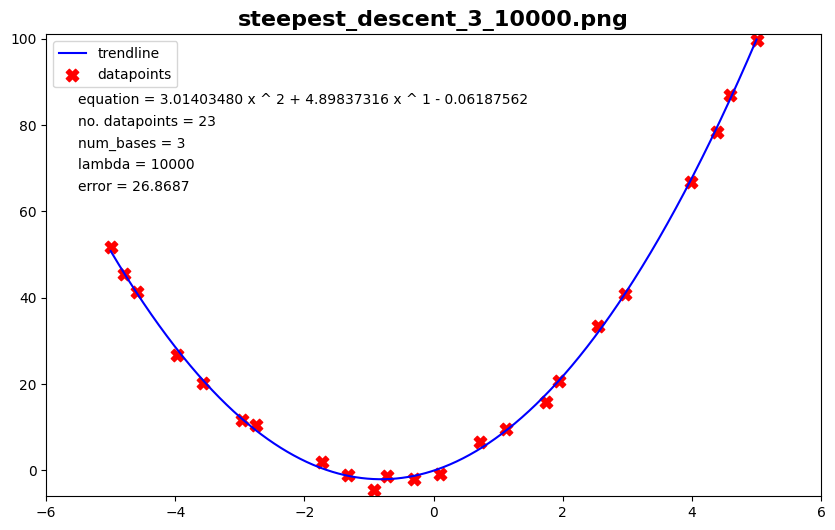

In [31]:
plot_datapoints_trendline(datapoints_arr, 
                          num_polynomial_bases, 
                          lambda_val,
                          equation,
                          error,
                          f"steepest_descent_{num_polynomial_bases}_{lambda_val}.png")